In [114]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

🔵 LOAD ALL DFS (FEATURES AND CLINICAL BIOMARKERS)

In [115]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

pd.set_option('future.no_silent_downcasting', True)
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1,'Stage 2': 2,'Stage 3': 3})
clinical_df = clinical_df.dropna(subset=['Stage'])
clinical_df['Stage'] = clinical_df['Stage'].astype(int)

df_c25 = pd.read_csv(r"D:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
df_vmi40 = pd.read_csv(r"D:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
df_vmi80 = pd.read_csv(r"D:\CSV\merged\merged_monoe_80kev_radiomics_spine_lesions_features.csv")
df_vmi120 = pd.read_csv(r"D:\CSV\merged\merged_monoe_120kev_radiomics_spine_lesions_features.csv")
df_konv = pd.read_csv(r"D:\CSV\merged\merged_konv_radiomics_spine_lesions_features.csv")

🔵 TRAIN AND TEST MODEL BASED ON IMAGE FEATURES FOR EVERY DF

Accuracy for df: CaSupp_25: 0.714


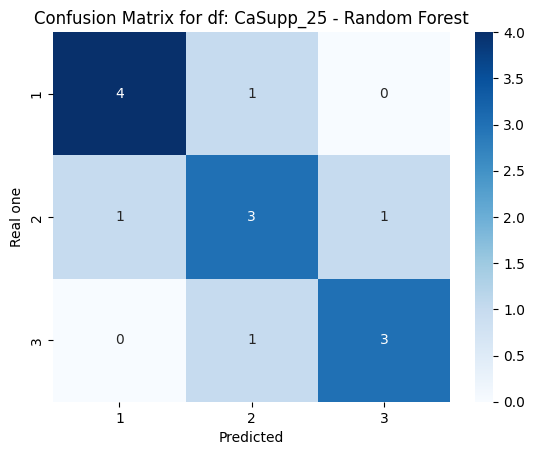

Accuracy for df: Konv: 0.500


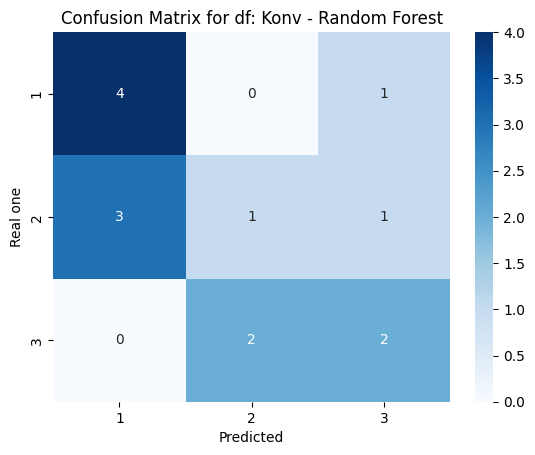

Accuracy for df: VMI_40: 0.714


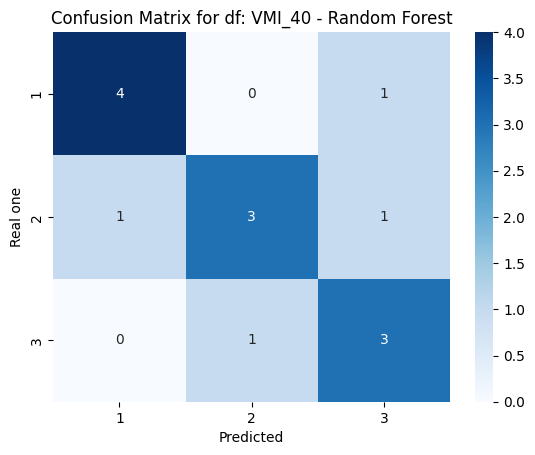

Accuracy for df: VMI_80: 0.714


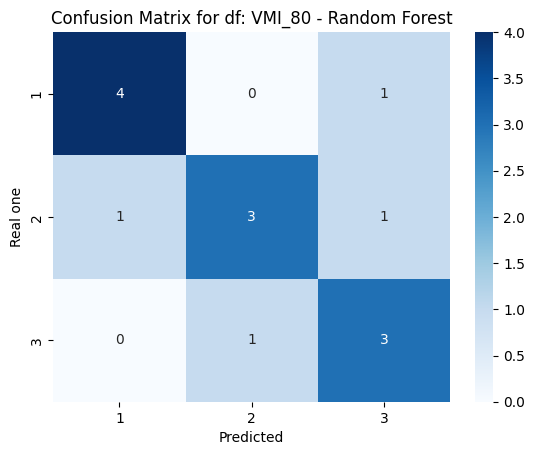

Accuracy for df: VMI_120: 0.571


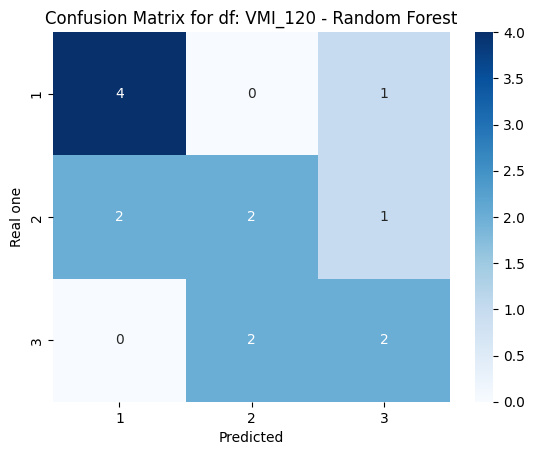

In [127]:
dfs = [df_c25, df_konv, df_vmi40, df_vmi80, df_vmi120]
dataset_names = ['CaSupp_25', 'Konv', 'VMI_40', 'VMI_80', 'VMI_120']

for df, name in zip(dfs, dataset_names):

    X = df.select_dtypes(include=['number'])
    y = clinical_df['Stage']

    valid_idx = X.notna().all(axis=1) & y.notna()
    X = X[valid_idx]
    y = y[valid_idx]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy for df: {name}: {acc:.3f}")

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1,2,3], yticklabels=[1,2,3])
    plt.xlabel("Predicted")
    plt.ylabel("Real one")
    plt.title(f"Confusion Matrix for df: {name} - Random Forest")
    plt.show()

🔵 TRAIN AND TEST MODEL BASED JUST ON CLINICAL BIOMARKER

Accuracy: 1.000


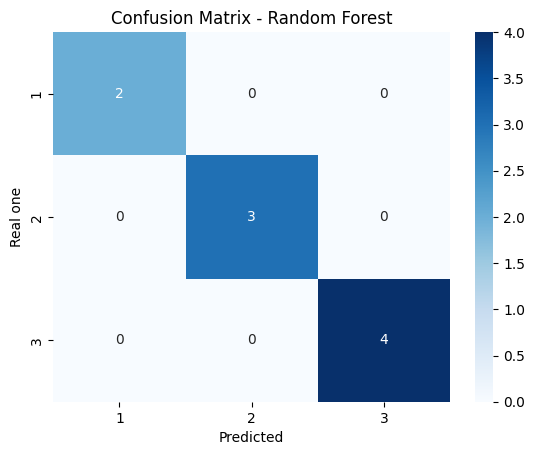

In [129]:
X = clinical_df.select_dtypes(include=['number']).drop(columns='Stage')
y = clinical_df['Stage']

valid_idx = X.notna().all(axis=1) & y.notna()
X = X[valid_idx]
y = y[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1,2,3], yticklabels=[1,2,3])
plt.xlabel("Predicted")
plt.ylabel("Real one")
plt.title(f"Confusion Matrix - Random Forest")
plt.show()

🔵 IMPORTANCE OF FEATURES FROM RANDOM FOREST MODEL

In [130]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)
feature_importance

Beta2 microglobulin (mg/l)          0.425441
Creatinine level (µmol/l)           0.138436
Calcium total level (mmol/l)        0.088341
Serum kappa FLC quantity (mg/l      0.083309
Plasmocyte count FC (%)             0.067146
Serum M-protein quantity (g/l)      0.060407
IgA quantity (g/l)                  0.052786
IgM quantity (g/l)                  0.045965
Serum lambda FLC quantity (mg/l)    0.019464
IgG quantity (g/l)                  0.018705
dtype: float64

🔵 RANDOM FOREST USING SELECTED FEATURES FROM K-W test (at least 2 significant result from 3 pairs)